# Snowpack -> Hydropower -> Electricity Prices

**Question:** Does winter/spring California snowpack predict summer electricity
price behavior through hydroelectric generation?

**Panel (data/processed/panel.csv):** one row per year --
`snowpack_pct` (April 1 snow water content as % of normal), summer day-ahead
price features (`price_mean`, `price_peak`, `price_vol`, `price_vol_hourly`),
summer hydro generation (`hydro_gwh`, `hydro_gwh_eia`), and controls
(`temp_mean_c`, `heat_days_38c`, `demand_mean_mw`, `gas_mean`).

**Price window:** 2016-2018 + 2023-2025 (6 years; CAISO's public archive has a
2019-2022 gap). Walk-forward uses min_train=3 -> 3 genuinely held-out years.

## Setup

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 110

## Walk-forward backtest (expanding window, strictly out-of-sample)

In [2]:
from src.models import walk_forward, rmse_table, dm_test, first_stage

panel = pd.read_csv(ROOT / 'data' / 'processed' / 'panel.csv', index_col=0)

wf = walk_forward(panel, target='price_vol', min_train=3)
rmse_table(wf)

,rmse,mae,n
model,,,
augmented_arimax,8.600,7.410,3
baseline_arima,8.600,7.410,3
baseline_naive,8.600,7.410,3
augmented_ols,9.138,7.778,3
baseline_mean3,12.080,11.830,3


### Diebold-Mariano test: augmented vs each baseline (squared errors)

In [3]:
for base in ['baseline_naive', 'baseline_mean3', 'baseline_arima']:
    a = wf[wf.model == 'augmented_ols'].set_index('year').error
    b = wf[wf.model == base].set_index('year').error
    both = a.index.intersection(b.index)
    d = dm_test(a.loc[both].values, b.loc[both].values)
    print(f'{base:18s} DM={d["dm"]:+.3f}  p={d["p"]:.3f}  n={d["n"]}')

# The first stage of the causal chain has far more data (2018-2025):
print()
print('First stage: snowpack -> summer hydro output (full record)')
print(first_stage(panel, mediator='hydro_gwh'))

baseline_naive     DM=+0.116  p=0.907  n=3
baseline_mean3     DM=-1.208  p=0.227  n=3
baseline_arima     DM=+0.116  p=0.907  n=3

First stage: snowpack -> summer hydro output (full record)
{'n': 8, 'slope_gwh_per_pct': 24.880021156975644, 'p_value': 0.022213686559705664, 'r2': 0.6095283325247278, 'pearson_r': 0.7807229550389357}


### Monthly panel: 4x the observations

In [4]:
from src.features import build_monthly_panel

mp = build_monthly_panel()
print(f'monthly rows: {len(mp)}  (vs {len(panel.dropna(subset=["price_vol"]))} annual)')
mp.dropna(subset=['price_vol']).head(12)

monthly rows: 24  (vs 6 annual)


,year,month,price_mean,price_vol,snowpack_pct,hydro_gwh,temp_mean_c
1,2016,6,30.079797,4.738954,90.999651,NaN,36.816667
2,2016,7,33.689022,6.254643,90.999651,NaN,38.793548
3,2016,8,36.270717,3.307798,90.999651,NaN,37.632258
4,2016,9,36.462286,3.528800,90.999651,NaN,33.963333
6,2017,6,35.778758,19.599208,174.480058,NaN,35.140000
7,2017,7,38.220588,4.425188,174.480058,NaN,38.709677
8,2017,8,47.978284,22.282200,174.480058,NaN,37.461290
9,2017,9,43.075089,20.336648,174.480058,NaN,32.093333
11,2018,6,31.993102,7.034567,62.326169,2131.505083,35.546667
12,2018,7,61.192454,40.885874,62.326169,2337.805167,39.622581


### Forecasts vs actual

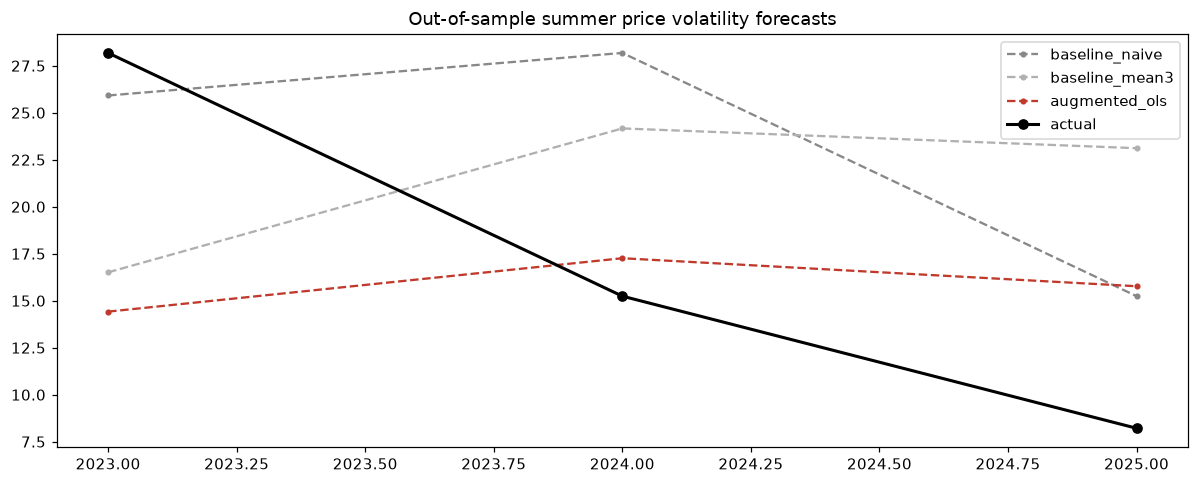

In [5]:
fig, ax = plt.subplots(figsize=(11, 4.5))
for model, color in [('baseline_naive', '#888888'), ('baseline_mean3', '#b0b0b0'),
                     ('augmented_ols', '#c0392b')]:
    m = wf[wf.model == model].set_index('year')
    ax.plot(m.index, m.pred, ls='--', marker='.', color=color, label=model)
actual = wf[wf.model == 'augmented_ols'].set_index('year').actual
ax.plot(actual.index, actual, ls='-', marker='o', color='black', lw=2, label='actual')
ax.set_title('Out-of-sample summer price volatility forecasts')
ax.legend(); plt.tight_layout(); plt.show()

> Backtest takeaway: fill in after running -- did adding snowpack lower
> out-of-sample RMSE vs persistence? Is the DM test significant?